**Library Importing**

In [15]:
import kagglehub
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential,layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
%matplotlib inline

**Data Loading From Kaggle Website**

In [2]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
path = path+"/chest_xray"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia/chest_xray


In [3]:
train_path = path+"/train"

# Step 1: Count images in each class
normal_images = os.listdir(os.path.join(train_path, "NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_path, "PNEUMONIA"))

n_normal = len(normal_images)
n_pneumonia = len(pneumonia_images)
print(f"Number of NORMAL images: {n_normal}")
print(f"Number of PNEUMONIA images: {n_pneumonia}")

Number of NORMAL images: 1341
Number of PNEUMONIA images: 3875


In [4]:
# Writable path
balanced_train_path = "/kaggle/working/train_balanced"

# Class folders
classes = ["NORMAL", "PNEUMONIA"]
os.makedirs(balanced_train_path, exist_ok=True)

target_count = min(n_normal, n_pneumonia)
print(f"Balancing to {target_count} images per class.")

# Sample and copy
for cls in classes:
    src_dir = os.path.join(train_path, cls)
    dst_dir = os.path.join(balanced_train_path, cls)
    os.makedirs(dst_dir, exist_ok=True)

    images = os.listdir(src_dir)
    sampled = random.sample(images, target_count)

    for img in sampled:
        src_path = os.path.join(src_dir, img)
        dst_path = os.path.join(dst_dir, img)
        shutil.copy(src_path, dst_path)

print("✅ Balanced training folder created at:", balanced_train_path)

Balancing to 1341 images per class.
✅ Balanced training folder created at: /kaggle/working/train_balanced


In [5]:
test_path = path+"/test"

# Just rescaling, no splitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,         # Small rotations to simulate patient posture variation
    zoom_range=0.1,            # Slight zoom to simulate scale variation
    width_shift_range=0.1,     # Horizontal shifts
    height_shift_range=0.1,    # Vertical shifts
    horizontal_flip=True,      # Chest X-rays can be flipped if medically valid
    fill_mode='nearest'        # Fill empty pixels after transformation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load from separate folders
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


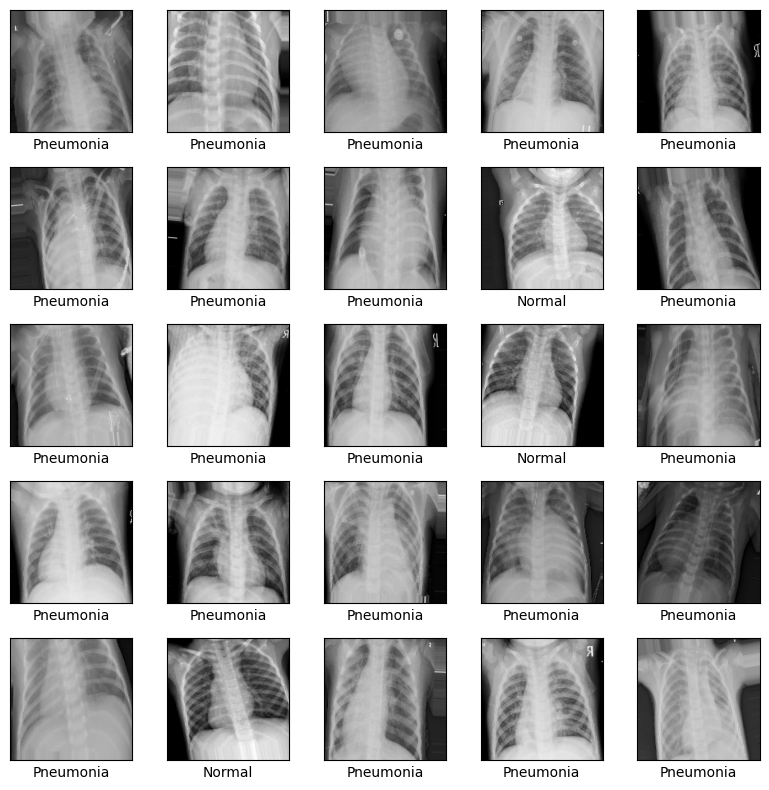

In [6]:
images, labels = next(train_generator)
plt.figure(figsize=(8,8))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(images[i])
  plt.xlabel("Pneumonia" if labels[i] == 1 else "Normal")
plt.tight_layout()
plt.show()

In [10]:
data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])
model = models.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,

    layers.Conv2D(4, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(8, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(8, activation='relu', kernel_regularizer = tf.keras.regularizers.L2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])


model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 148, 148, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 74, 74, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 72, 72, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │        82,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,369 (325.66 KB)

 Trainable params: 83,369 (325.66 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer = 'adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=(False)),
              metrics=['accuracy'])

history = model.fit(train_generator, epochs=15,batch_size=32,
                    validation_data=(test_generator))

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 469ms/step - accuracy: 0.8596 - loss: 0.3406 - val_accuracy: 0.8478 - val_loss: 0.4079
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 445ms/step - accuracy: 0.8578 - loss: 0.3536 - val_accuracy: 0.8381 - val_loss: 0.4873
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 470ms/step - accuracy: 0.8784 - loss: 0.3122 - val_accuracy: 0.8766 - val_loss: 0.3805
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 460ms/step - accuracy: 0.8817 - loss: 0.3189 - val_accuracy: 0.8061 - val_loss: 0.5304
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 581ms/step - accuracy: 0.8677 - loss: 0.3332 - val_accuracy: 0.8638 - val_loss: 0.3605
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 456ms/step - accuracy: 0.8715 - loss: 0.3398 - val_accuracy: 0.8654 - val_loss: 0.4049
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 447ms/step - accuracy: 0.8861 - loss: 0.3031 - val_accuracy: 0.8862 - val_loss: 0.3706
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.8941 - loss: 0

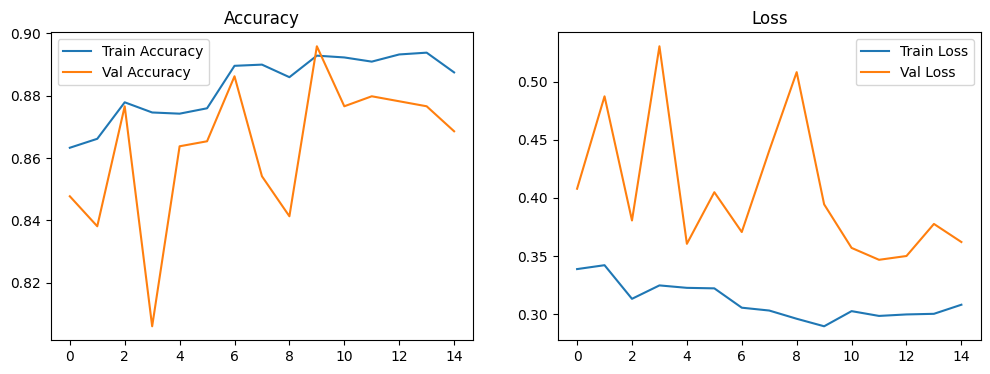

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.savefig('accuracy_loss.png')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step
              precision    recall  f1-score   support

      Normal       0.78      0.91      0.84       234
   Pneumonia       0.94      0.84      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.88      0.86       624
weighted avg       0.88      0.87      0.87       624



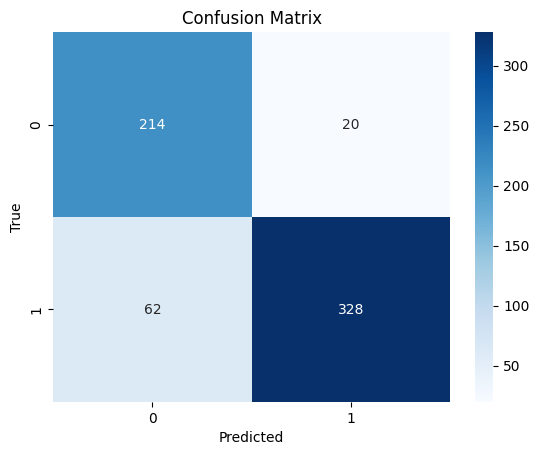

In [18]:

y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

report = classification_report(y_true, y_pred, target_names = ['Normal','Pneumonia'])
print(report)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()
